# Supplemental - Elements, Sections, Supports, and Solver Results

Use this after Notebooks 01 through 03 when you want one compact notebook that exercises many element and support types together.

1. Build pipes, beams, bars, cables, rectangular sections, and an I-beam.
2. Add anchors, springs, custom blocked DOFs, rests, and concentrated mass.
3. Inspect the model geometry interactively.
4. Run or import Code_Aster artifacts before rendering stress, displacement, or reaction results.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pyvista as pv

# Setup repo root for path import
REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tuba import Model
from tuba.analysis.code_aster_notebook import configure_code_aster_notebook_runtime, load_or_run_code_aster_results
from tuba.plotting import plots
from tuba.plotting.notebook import configure_notebook_backend

# Enable interactive notebook rendering.
# Defaults to zoomable embedded HTML locally; set TUBA_NOTEBOOK_BACKEND=client or static to override.
JUPYTER_BACKEND = configure_notebook_backend()
CODE_ASTER_RUNTIME = configure_code_aster_notebook_runtime()


## 1. Construct the Model with All Element & Section Types

We will construct a 3D piping system that includes all element types and section profiles:
- Pipe straight and bends (`PipeSec`)
- Solid/Hollow bar (`BarSec`)
- Tension-only cable (`CableSec`)
- Hollow box beam (`RectSec`)
- Standard I-beam (`IBeamSec` loaded from database)

In [2]:
model = Model("Tuba_v4_Demo_Study")

# 1. Materials
model.add_material("Steel", E=2.0e11, nu=0.3, alpha=1.2e-5, rho=7850)

# 2. Sections
model.add_pipe_section("PipeSec", OD=0.1143, WT=0.006)
model.add_bar_section("BarSec", OD=0.05, WT=0.0)  # Solid bar
model.add_cable_section("CableSec", radius=0.01, pretension=500.0)
model.add_rectangular_section("RectSec", height_y=0.08, height_z=0.04, thickness_y=0.005, thickness_z=0.005)

# Load I-Beam from local database
try:
    model.add_ibeam_section("IBeamSec", "IPE100")
except Exception:
    # Fallback in case of custom run environment
    from tuba.model import IBeamSection
    model.sections["IBeamSec"] = IBeamSection(name="IBeamSec", profile_name="IPE100", properties={
        "A": 1.03e-3, "IY": 1.71e-6, "IZ": 1.59e-7, "JX": 1.2e-8, "RY": 4.07e-2, "RZ": 1.24e-2
    })

# 3. PipingBuilder - Routing elements
with model.pipe(section="PipeSec", material="Steel") as b:
    b.start([0, 0, 0], support="anchor")
    b.run(2.0)
    b.bend(radius=0.2, angle=90, plane="XY")
    b.run(1.5)

# Add beam, bar, cable, and rectangular elements
with model.pipe(section="IBeamSec", material="Steel") as b:
    b.start([2.2, 1.7, 0]).beam(1.5)

with model.pipe(section="BarSec", material="Steel") as b:
    b.start([3.7, 1.7, 0]).bar(1.0)

with model.pipe(section="CableSec", material="Steel") as b:
    b.start([4.7, 1.7, 0]).cable(2.0)

with model.pipe(section="RectSec", material="Steel") as b:
    b.start([6.7, 1.7, 0]).beam(1.2)

## 2. Define Advanced Supports

Now, we add advanced support configurations:
- **N1:** Spring support with translational stiffness in Y (`stiffness_matrix=[0.0, 1.5e6, 0.0, 0.0, 0.0, 0.0]`).
- **N2:** Custom boundary condition with translations in X and Y blocked, rotation in Z blocked (`blocked_dof=[1, 1, 0, 0, 0, 1]`).
- **N3:** Spring matrix support with custom directional stiffnesses.
- **N4:** Rest support supporting a concentrated mass of 50 kg.
- **N7:** Terminal custom restraint for the secondary beam branch so the Code_Aster solve has no free rigid-body rotation.

The direct node names below come from the construction order in the previous cell. Use the printed/visualized geometry to confirm which physical point a node id refers to before attaching restraints in real models.

In [3]:
# Node N0 is anchor (set during start)
# Let's add other supports
model.add_support(node="N1", type="spring", stiffness_matrix=[0.0, 1.5e6, 0.0, 0.0, 0.0, 0.0])
model.add_support(node="N2", type="custom", blocked_dof=[1, 1, 0, 0, 0, 1])
model.add_support(node="N3", type="spring", stiffness_matrix=[1e5, 2e5, 3e5, 0.0, 0.0, 0.0])
model.add_support(node="N4", type="rest", mass=50.0)
model.add_support(node="N7", type="custom", blocked_dof=[1, 1, 1, 1, 1, 1])

model.define_load_case("LoadCase1", gravity=True, pressure=1.0e6, temperature=120.0)

print("Supports in model:")
for s in model.supports:
    print(f"Node: {s.node:4} | Type: {s.type:8} | stiffness_matrix: {s.stiffness_matrix} | blocked_dof: {s.blocked_dof}")

Supports in model:
Node: N0   | Type: anchor   | stiffness_matrix: None | blocked_dof: None
Node: N1   | Type: spring   | stiffness_matrix: [0.0, 1500000.0, 0.0, 0.0, 0.0, 0.0] | blocked_dof: None
Node: N2   | Type: custom   | stiffness_matrix: None | blocked_dof: [1, 1, 0, 0, 0, 1]
Node: N3   | Type: spring   | stiffness_matrix: [100000.0, 200000.0, 300000.0, 0.0, 0.0, 0.0] | blocked_dof: None
Node: N4   | Type: rest     | stiffness_matrix: None | blocked_dof: None
Node: N7   | Type: custom   | stiffness_matrix: None | blocked_dof: [1, 1, 1, 1, 1, 1]


## 3. Visualizing 3D Model Geometry and Supports

Let's use our new interactive PyVista plotting helpers to render the 3D model, the 3D obstacles (if any), and the 3D supports.
Supports are displayed as:
- **Red Cube:** Anchor
- **Green Cylinder:** Guide
- **Blue Cone:** Rest/Bearing
- **Yellow Sphere:** Spring
- **Magenta Sphere:** Custom/Other

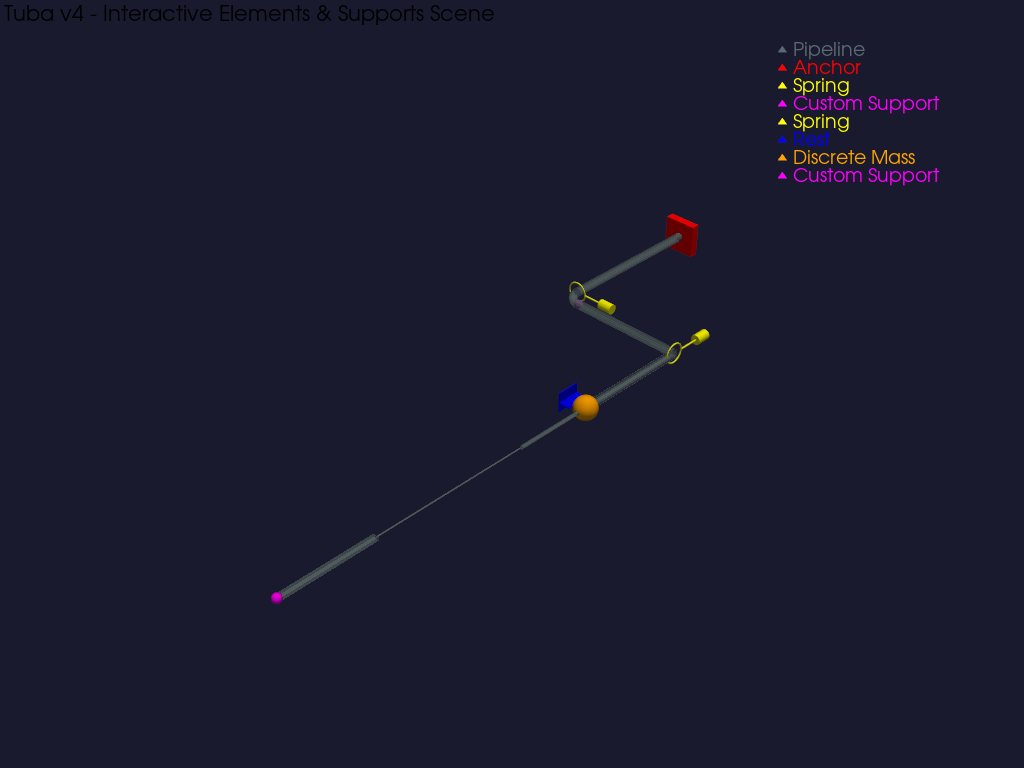

In [4]:
from tuba.plotting.pipeline import build_3d_mesh_from_model

# True section geometry straight from the model — each element renders its
# real profile (pipe, bar, cable, box, I-beam), no inflation radius to tune.
tubes = build_3d_mesh_from_model(model)

# Render scene
p = pv.Plotter()
p.set_background("#1a1a2e")
p.add_text("Tuba v4 - Interactive Elements & Supports Scene", position="upper_left", font_size=12)

p.add_mesh(tubes, color="#5c6b73", opacity=0.85, label="Pipeline")

# Add supports using our new helper
plots._add_supports_to_plotter(p, model, scale=0.18)

p.add_legend(bcolor="#1a1a2e")
p.show(jupyter_backend=JUPYTER_BACKEND)

## 4. Run Code_Aster and Render FEA Results

This section uses the shared notebook loader. It exports the study, imports existing Code_Aster result tables when they are present, or executes the configured Code_Aster runtime when tables are missing. If Code_Aster cannot run and the tables are absent, the cell stops before plotting solver results.


Failed to read .rmed: 'SP_PIPE SE3'


Failed to read .rmed: 'SP_PIPE SE3'


Result source: ran Code_Aster
Work directory: D:\Gitprojects\Tuba_v4\notebooks\code_aster_results\elements_supports_loadcase1
Node results: 8
Element results: 7


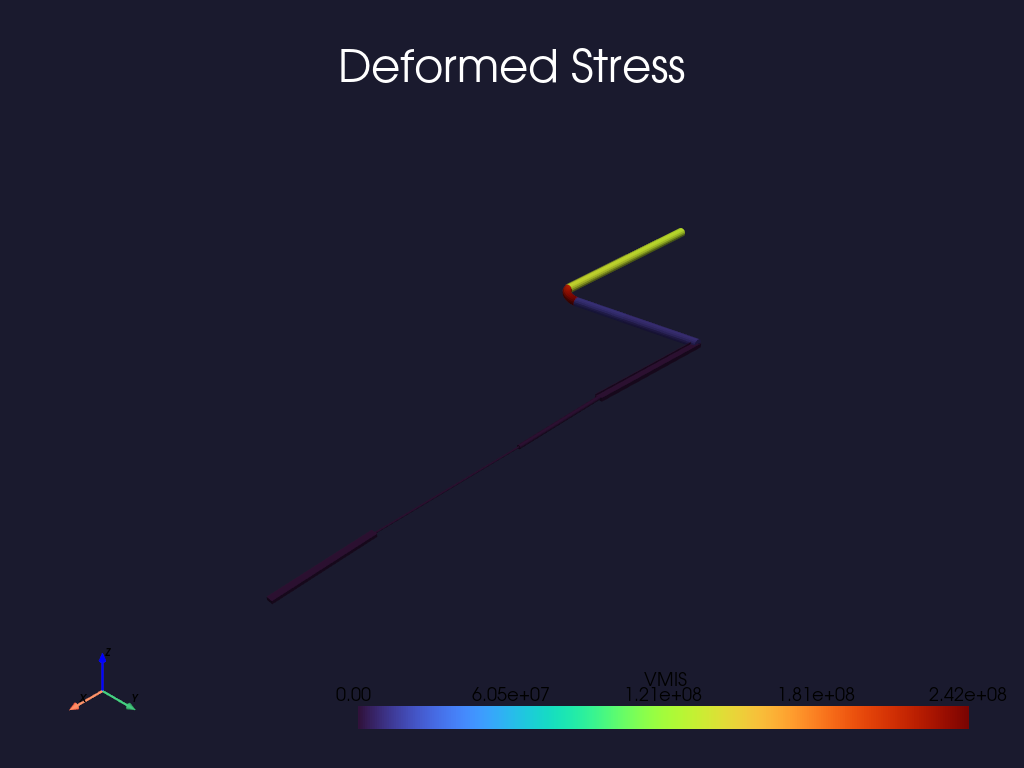

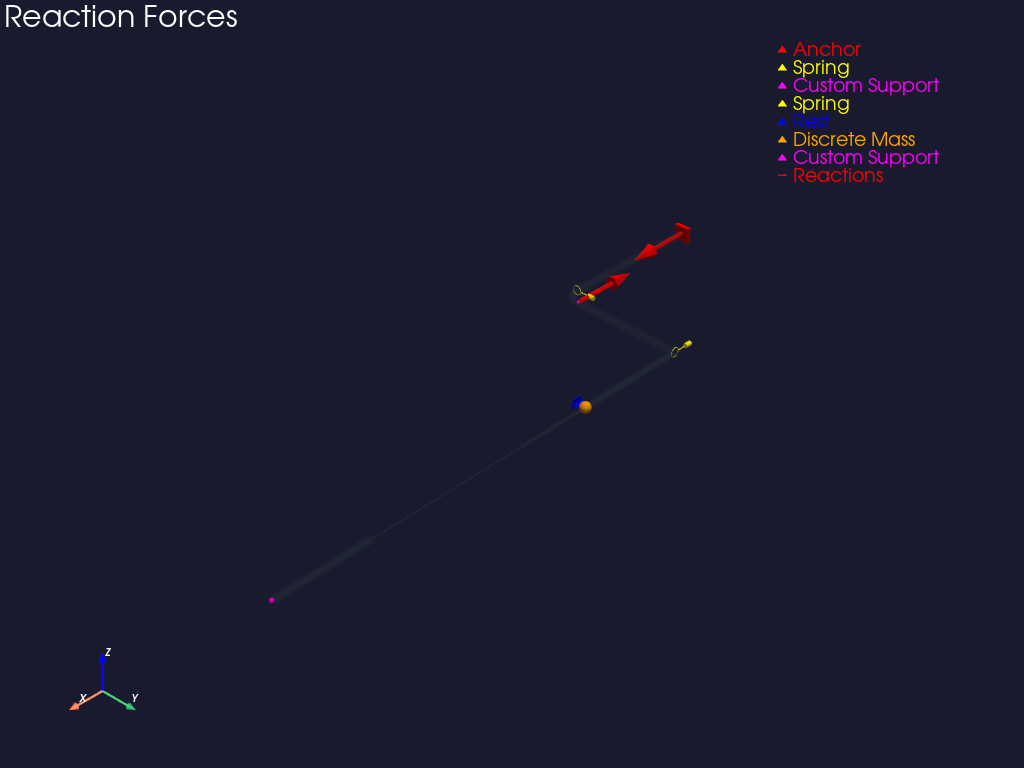

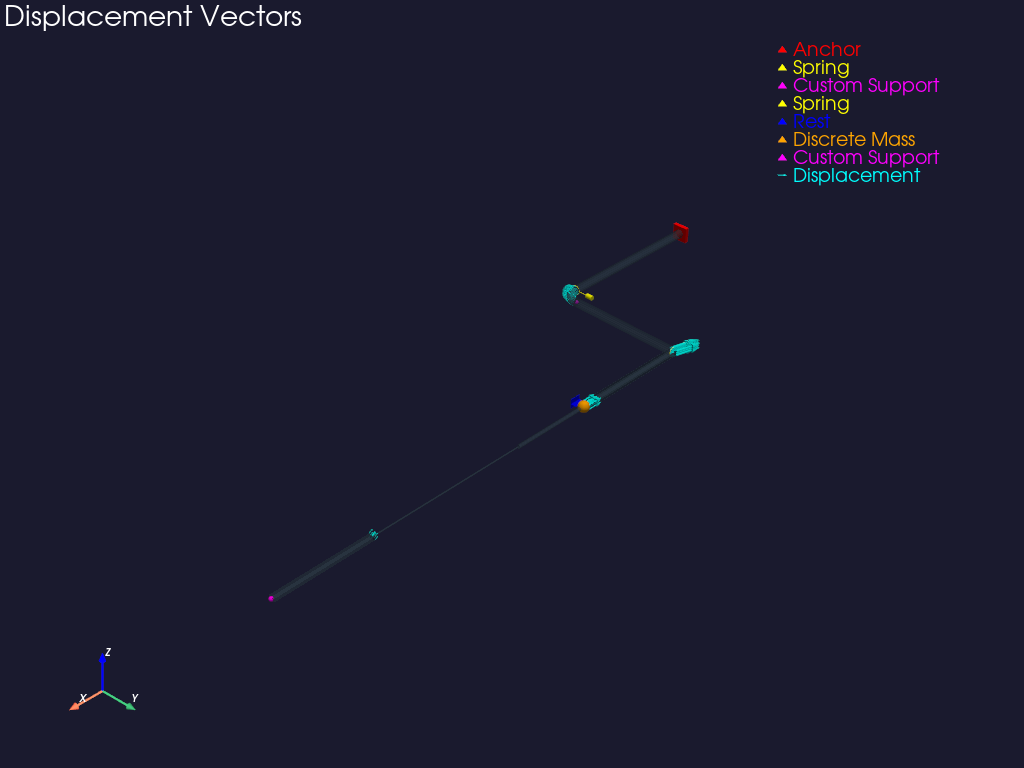

In [5]:
RUN_CODE_ASTER = True
CODE_ASTER_WORK_DIR = REPO_ROOT / "notebooks" / "code_aster_results" / "elements_supports_loadcase1"

code_aster_run = load_or_run_code_aster_results(
    model,
    "LoadCase1",
    CODE_ASTER_WORK_DIR,
    run_solver=RUN_CODE_ASTER,
    exec_method=CODE_ASTER_RUNTIME.exec_method,
    wsl_distro=CODE_ASTER_RUNTIME.wsl_distro,
    docker_image=CODE_ASTER_RUNTIME.docker_image,
)
results = code_aster_run.results
code_aster_artifact = code_aster_run.artifact

source = "ran Code_Aster" if code_aster_run.ran_solver else "loaded existing Code_Aster tables"
print(f"Result source: {source}")
print(f"Work directory: {CODE_ASTER_WORK_DIR.resolve()}")
print(f"Node results: {len(results.node_results)}")
print(f"Element results: {len(results.element_results)}")

plots.plot_deformed_stress(results, deform_scale=50.0, model=model, jupyter_backend=JUPYTER_BACKEND)
plots.plot_reactions(results, scale="auto", model=model, geometry_opacity=0.2, jupyter_backend=JUPYTER_BACKEND)
plots.plot_displacement_vectors(results, scale=50.0, model=model, jupyter_backend=JUPYTER_BACKEND)
